# Proyecto de Minería de Datos — Hito 2

**Integrantes:**
- Andrés Franz (Introducción, Exploración de Datos, Propuesta Experimental)
- Tomás Albornoz (Propuesta Experimental, Pregunta 1, Pregunta 2)
- Emilio Torres (Pregunta 2)
- Esperanza Cares (Pregunta 3, Presentación, Conclusión)
- Sebastián Romero (Pregunta 3)

## 1. Introducción y motivación

Para este proyecto utilizamos el dataset `hotel_bookings` (dos hoteles: City y Resort) para responder preguntas concretas de negocio:
- **Predicción de cancelación** a partir de variables operativas (mes de llegada, tipo de cliente, `lead_time` y duración de estadía).
- **Pesos de atributos en relación al ADR**
- **Segmentación de reservas** (clustering) para descubrir grupos con comportamientos similares (p. ej., reservas cortas/anticipadas vs. largas/último minuto).

Decidimos usar este dataset porque nos llamó la atención la gran cantidad de registros disponibles (más de 100 000 reservas) y la variedad de atributos que ofrece: fechas, precios, tipos de clientes, canales de distribución, duración de estadías, entre otros. Consideramos que disponer de un conjunto de datos tan extenso y diverso nos permitiría explorar múltiples preguntas interesantes, desde patrones estacionales hasta factores asociados a las cancelaciones de reservas.

Además, nos interesó el contexto práctico: la gestión hotelera es un área donde el análisis de datos puede tener un impacto directo en las decisiones de negocio, como la política de precios, la sobreventa controlada o la segmentación de clientes. En particular, vimos la oportunidad de aplicar distintas técnicas de minería de datos, tanto supervisadas (para predecir cancelaciones) como no supervisadas (para agrupar reservas con características similares), lo que hace de este proyecto una buena instancia de aprendizaje y experimentación.


## 2. Exploración de datos

El conjunto de datos original contenía **119 390 filas y 32 columnas**, pero tras el proceso de limpieza —que incluyó la revisión de valores nulos y la eliminación de duplicados— quedó reducido a **86 940 filas y 30 columnas**, suprimiendo las variables **`agent`** y **`company`** debido a su alto porcentaje de valores faltantes. Al analizar los distintos gráficos (*ver código fuente*), se observa una **marcada estacionalidad**, ya que la mayor concentración de reservas ocurre en **julio y agosto**, lo que sugiere que el mes de llegada puede influir tanto en la demanda como en el riesgo de cancelación. Asimismo, se identificó que **el tipo de habitación, el mes del año y el tipo de hotel** afectan el **precio promedio por noche (ADR)**, que tiende a elevarse durante los meses de mayor demanda y en ciertas categorías de habitación, reflejando el comportamiento propio de las **temporadas altas**.
Finalmente, los gráficos sobre **tasas de cancelación** muestran que estas varían según distintas características de la reserva: las **reservas realizadas con mucha anticipación, estadías prolongadas o efectuadas por clientes individuales** parecen tener una **menor percepción del costo de cancelar**, lo que las hace **más propensas a ser canceladas**, evidenciando la influencia conjunta de factores económicos y conductuales sobre este fenómeno.


## 3. Preguntas y problemas

**P1. ¿Se puede predecir la cancelación de una reserva** en base a *mes de llegada*, *tipo de cliente*, *lead time* y *duración de estadía*?  
- Variable objetivo: `is_canceled` (binaria).  
- Relevancia: permite gestionar sobreventa, políticas de depósito y asignación de inventario.

**P2. ¿Qué atributos tienen más peso en el precio (ADR)?**  
- Variable explicativa: `adr` (Average Daily Rate).

**P3. ¿Existen grupos de reservas con características similares?**  
- Enfoque no supervisado (clustering) con variables operativas (`lead_time`, `adr`, `total_noches`, y codificaciones de cliente/segmento).  
- Objetivo: perfilar segmentos para acciones diferenciadas (depósitos, sobreventa, pricing).

## 4. Propuesta metodológica experimental

**Preprocesamiento común**  
- `total_noches = stays_in_weekend_nights + stays_in_week_nights`  
- Imputación: numéricas con **mediana**; categóricas con **moda**/`'Unknown'`.  
- Codificación: **One-Hot** para categóricas.  
- Escalado: **StandardScaler** en numéricas para modelos lineales y K-Means.  
- Partición: `train/test = 80/20` (estratificando `is_canceled`).

**P1 – Clasificación (predicción de cancelación)**  
- Modelos: **Regresión Logística** (baseline) + **Árboles/Random Forest** (no lineales).  
- Variables: `arrival_date_month`, `customer_type`, `lead_time`, `total_noches`, entre otras.  
- Métricas: **Accuracy**, **F1**, **ROC-AUC** y **matriz de confusión**.  
- Interpretación: coeficientes (logística) e **importancia** (árboles/forest).

**P2 – Peso de atributos en relación a ADR**  
- Analizar los pesos de los atributos con Lasso.
- Ver si tiene sesgo (modelo con correlacion).
- Seleccionar los mejores.

**P3 – Clustering (segmentación)**  
- Features: `lead_time`, `adr`, `total_noches`, `adults` + categóricas codificadas.  
- Algoritmo: **K-Means** (selección de `k` por codo y silhouette).  

**Riesgos y mitigaciones**  
- Desbalance en `is_canceled`: **estratificación**, `class_weight`, ajuste de umbral.  
- Outliers en `adr`/`lead_time`: winsorización o límites de ejes.  
- Sesgos estacionales/canales: incluir variables de control y análisis estratificado.

## 5. Experimento


### Pregunta 1

En esta preguntaba se buscaba respoder si se podria predecir la cancelación de una reserva en base a mes de llegada, tipo de cliente, lead time y duración de estadía.

Para esto, se corrió el código en Random Forest y Logistic Regression.

Para el primero, se eligieron 200 árboles, con una profundidad de 15 y un mínimo de muestras de 5, para dividir los módulos. Con esto, se consiguió un muy buen rendimiento en el set de prueba, pero no uno tan bueno para el otro.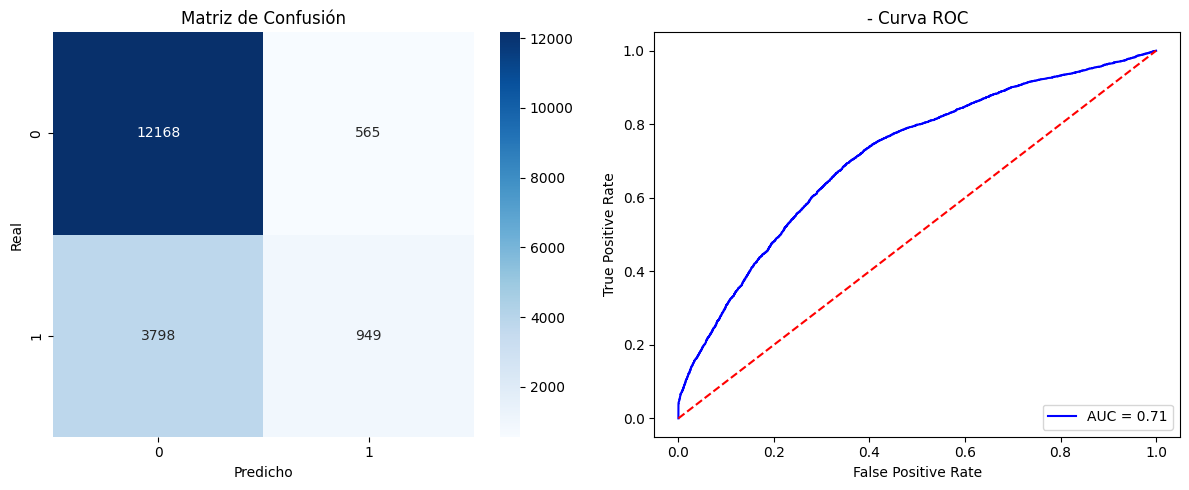


El modelo identifica de muy buena manera si la reserva permanecerá, pero suele fallar con la cancelación (una de las cuatro predicciones fallan sobre si se cancelará). En cuanto logistic regression, los resultados no difieren tanto del anterior, siendo:

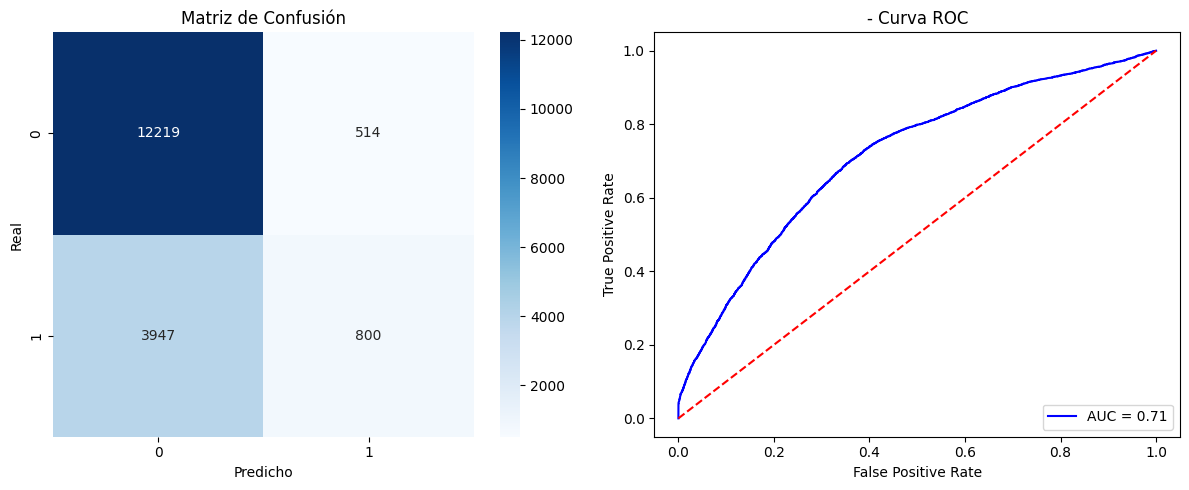

Dado estos datos, podemos llegar a la conclusión que con estas variables (mes, tipo cliente, lead time, duración), sí hay señales de comportamiento de cancelación, pero no son suficientes para un modelo predictivo confiable al 100% en cuanto a las cancelaciones.

Para este hito 2, modificamos los modelos agregando varios atributos más y también dejamos las clases balanceadas, con esto los resultados fueron los siguientes:

**random forest**

![Captura de pantalla 2025-12-02 163005.png](attachment:baa5b72f-c93b-42b2-938d-3bb3ec134de3.png)

**Logictic Regresion**
![Captura de pantalla 2025-12-02 163016.png](attachment:e8edb9e3-83c4-47b4-9807-dad20eafa9df.png)

Con esto, se puede ver que la incorporación de más variables en el modelo permitió una mejora en el rendimiento general, ya que la información adicional ayudó a capturar patrones relevantes asociados al comportamiento de las reservas. Además, aplicar class_weight="balanced" hizo que el modelo prestara más atención a la clase minoritaria (reservas canceladas), logrando un mejor equilibrio entre precision y recall, lo que se refleja especialmente en un aumento del F1-score para dicha clase. Sin embargo, a pesar de estas mejoras, los modelos aún no presentan un desempeño óptimo, ya que siguen teniendo dificultades para distinguir correctamente entre reservas que finalmente se cancelan y aquellas que no. Esto puede deberse tanto al desbalance natural del conjunto de datos como a la complejidad intrínseca del problema, donde factores externos no capturados en los atributos disponibles pueden influir en la decisión final de cancelar una reserva. Por lo tanto, si bien las modificaciones realizadas fortalecieron el modelo, todavía existe margen de mejora antes de considerarlo una herramienta predictiva realmente confiable.

### Pregunta 2

En esta sección se modeló el ADR, que corresponde a la tarifa diaria promedio, mediante un modelo lineal con regularización L1 (Lasso). Aunque inicialmente se trabajó con 28 variables, al transformar las categóricas con one hot encoding el modelo pasó a operar sobre 191 columnas, lo que permite capturar diferencias específicas por mes, país, segmento de mercado, tipo de habitación y características del servicio. El desempeño en test fue alto para este tipo de problema, con R2 = 0.816 y MAE = 19.47, y además supera ampliamente un baseline trivial que predice siempre el promedio del ADR, reduciendo el error casi a la mitad (MAE 39.08 a 19.47) y pasando de un R2 cercano a 0 a 0.816, lo que confirma que el modelo está aprendiendo patrones reales del dataset.

Respecto a qué variables pesan más y por qué eso es posible, los coeficientes más grandes reflejan principalmente estacionalidad y composición comercial de la reserva. En particular, meses como julio y agosto aparecen con coeficientes muy altos y positivos, lo que es coherente con el contexto de Portugal, donde el verano concentra una demanda turística fuerte y, por gestión de revenue, tiende a elevarse la tarifa promedio. También aparecen efectos grandes asociados a market segment, plan de comida y tipos de habitación, lo que es esperable porque el ADR está directamente ligado al “producto” vendido y al canal/segmento que lo compra; por ejemplo, un segmento como Complementary tenga un peso negativo fuerte es consistente con que agrupa reservas con tarifas muy reducidas o gratuitas, mientras que diferencias entre reserved_room_type y assigned_room_type capturan saltos de precio entre categorías de habitación. El coeficiente negativo de hotel_City Hotel debe leerse como un efecto relativo respecto del hotel base (por cómo funcionan las dummies), sugiriendo que, controlando por el resto, el City Hotel tiende a tener ADR menor que el de referencia, lo que cuadra con escenarios donde el resort o la oferta turística estacional empuja precios más altos. En variables numéricas, la matriz de correlación muestra relaciones moderadas con ADR (destacando children y adults), lo que sugiere que la ocupación influye, pero que el grueso del poder explicativo proviene de variables categóricas de temporada y mix comercial. Como implicancia, estos resultados son útiles para entender qué dimensiones conviene priorizar al explicar o anticipar ADR (temporada, segmento, habitación, plan), pero deben interpretarse como relaciones predictivas y relativas a categorías de referencia, no como causalidad; además, con muchas dummies algunas categorías poco frecuentes pueden producir coeficientes grandes por patrones específicos del conjunto, y el Lasso tiende a seleccionar “representantes” cuando hay variables correlacionadas, por lo que el ranking de importancia es más confiable que interpretar cada coeficiente como un efecto exacto aislado.

![Captura de pantalla 2025-12-02 181534.png](attachment:17659d05-2231-47b3-9b89-8b9251c4dc75.png)

### Pregunta 3

Para esta pregunta se utilizó el algoritmo de K-Means. Al evaluar distintos valores de k con Silhoute Score y el método del codo, el número óptimo de clusters fue k = 3, ya que obtuvo los valores más altos de cohesión y el quiebre más claro en la curva de SSE.

![Captura de pantalla 2025-12-02 170918.png](attachment:6b7a9e6a-ee35-4070-83d5-da33ae602875.png)

Estos fueron los resultados:

![image.png](attachment:28cecaa0-8eee-45f7-8bca-3d0a9369fe43.png)
![image.png](attachment:36844d81-6b48-499e-95d5-0ae5a6aad67d.png)

En base a esto, se puede decir que existen grupos de reservas con características similares. En general, el clustering permitió identificar algunos patrones interesantes en las reservas, agrupándolas según características compartidas, como por ejemplo: algunos clusters agrupan reservas con estancias cortas y ADR bajos, otros tienen lead_time muy alto, otros representan mayor duración de estadía o grupos familiares, también la proporción de cancelaciones varía entre los clusters, mostrando perfiles de mayor y menor propensión a cancelar. Sin embargo, la separación entre los grupos no fue del todo clara y existe superposición entre ellos, lo que sugiere que los atributos seleccionados no generan segmentos completamente distintos dentro del dataset. Esto puede deberse a que las variables disponibles no capturan aspectos más complejos del comportamiento del cliente, o a que el fenómeno en sí es continuo y no naturalmente segmentado. Por lo tanto, si bien los clusters entregan una idea inicial de posibles perfiles de reserva, estos resultados deben interpretarse con cautela, y probablemente requerirían más variables o modelos alternativos para obtener segmentaciones realmente útiles a nivel práctico.

## 6. Código fuente


In [ ]:
import os, sys, math, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans



- Leemos el archivo de reservas y verificamos estructura.

In [ ]:
df_hotel = pd.read_csv('hotel_bookings.csv', encoding="UTF-8")

- Mostramos las dimensiones iniciales

In [ ]:
df_hotel.shape

(119390, 32)

- Contamos la cantidad de filas duplicadas del dataset

In [ ]:
df_hotel.duplicated().sum()

np.int64(31994)

- Eliminamos los registros duplicados para evitar sesgos.

In [ ]:
df_hotel.drop_duplicates(inplace=True)

- Conteo de nulos por columna para decidir imputación o descarte.

In [ ]:
df_hotel.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


- Desechamos las columnas 'agent' y 'company' por la gran cantidad de nulos, además que no aportan mucha información

In [ ]:
df_hotel = df_hotel.drop(columns=['agent','company'])

- Eliminamos las demás filas nulas y mostramos las dimensiones

In [ ]:
df_hotel.dropna().shape

(86940, 30)

- Algunas estadísticas de los datos

In [ ]:
df_hotel.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,87396,87396.000000,87396.000000,87396.000000,87396,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,...,87396,87396.000000,87396,87396.000000,87396,87396.000000,87396.000000,87396.000000,87396,87396
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,12,NaN,3,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,A,NaN,No Deposit,NaN,Transient,NaN,NaN,NaN,Check-Out,2016-02-14
freq,53428,NaN,NaN,NaN,11257,NaN,NaN,NaN,NaN,NaN,...,46313,NaN,86251,NaN,71986,NaN,NaN,NaN,63371,211
mean,NaN,0.274898,79.891368,2016.210296,NaN,26.838334,15.815541,1.005263,2.625395,1.875795,...,NaN,0.271603,NaN,0.749565,NaN,106.337246,0.084226,0.698567,NaN,NaN
std,NaN,0.446466,86.052325,0.686102,NaN,13.674572,8.835146,1.031921,2.053584,0.626500,...,NaN,0.727245,NaN,10.015731,NaN,55.013953,0.281533,0.831946,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,11.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,0.000000,NaN,0.000000,NaN,72.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,49.000000,2016.000000,NaN,27.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,0.000000,NaN,0.000000,NaN,98.100000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,125.000000,2017.000000,NaN,37.000000,23.000000,2.000000,4.000000,2.000000,...,NaN,0.000000,NaN,0.000000,NaN,134.000000,0.000000,1.000000,NaN,NaN


- ### Gráficos relacionados a los datos:
principalmente enfocados en el ADR (precio promedio por noche) Y las reservas canceladas

In [ ]:
import seaborn as sns

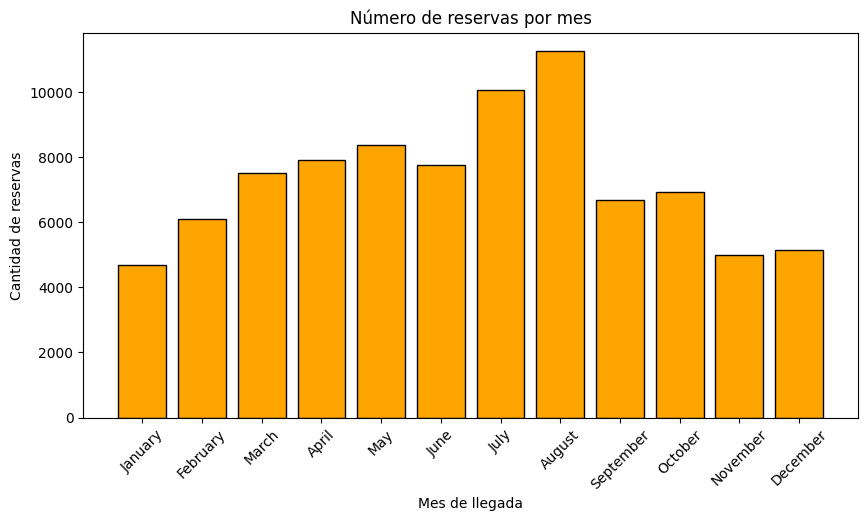

In [ ]:
orden_meses = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_hotel['arrival_date_month'] = pd.Categorical(
    df_hotel['arrival_date_month'],
    categories=orden_meses,
    ordered=True
)

counts = df_hotel['arrival_date_month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values, color='orange', edgecolor='black')
plt.xlabel('Mes de llegada')
plt.ylabel('Cantidad de reservas')
plt.title('Número de reservas por mes')
plt.xticks(rotation=45)
plt.show()



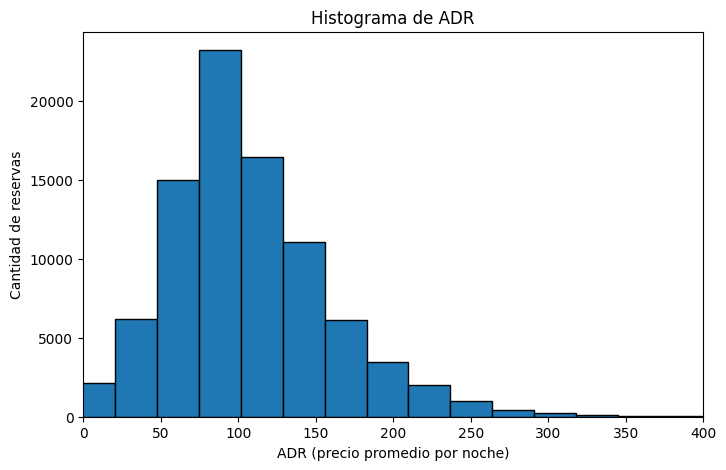

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_hotel['adr'], bins=200, edgecolor='black')
plt.xlabel('ADR (precio promedio por noche)')
plt.ylabel('Cantidad de reservas')
plt.title('Histograma de ADR')
plt.xlim(0, 400)
plt.show()


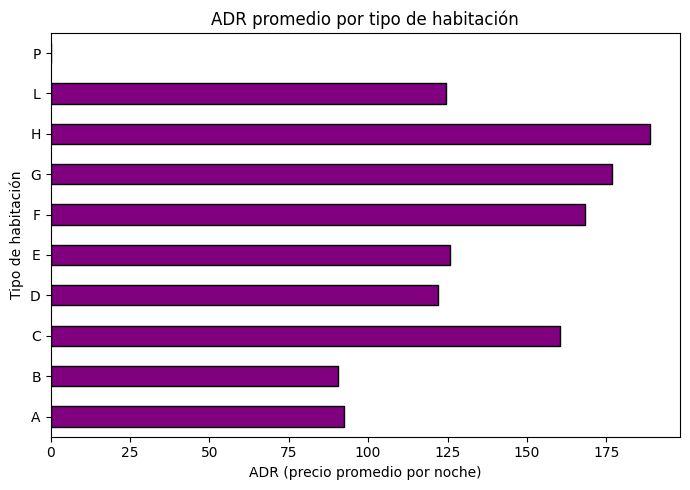

In [ ]:
adr_habitacion = (
    df_hotel.groupby('reserved_room_type')['adr']
            .mean()
)

plt.figure(figsize=(7,5))
adr_habitacion.plot(kind='barh', color='purple', edgecolor='black')
plt.xlabel('ADR (precio promedio por noche)')
plt.ylabel('Tipo de habitación')
plt.title('ADR promedio por tipo de habitación')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2934324448.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hotel.groupby(['arrival_date_month','hotel'])['adr']


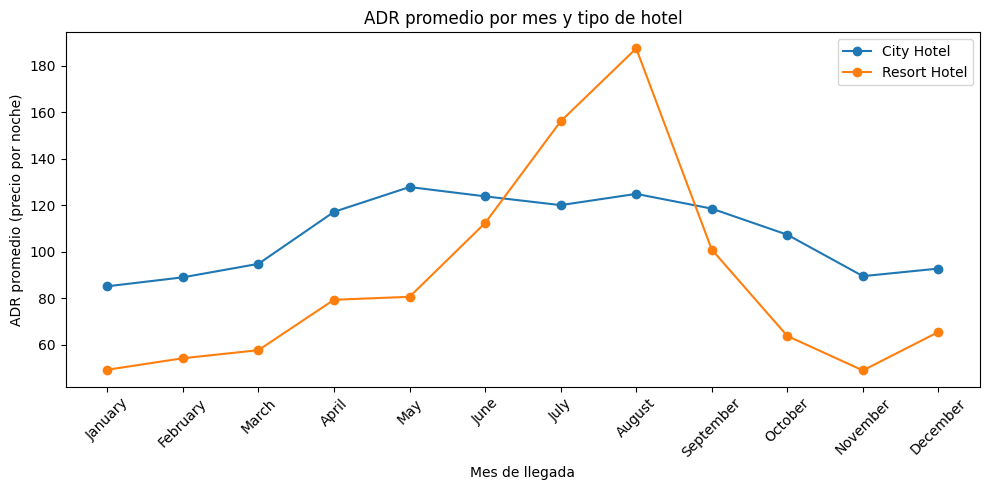

In [ ]:
orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_hotel['arrival_date_month'] = pd.Categorical(
    df_hotel['arrival_date_month'], categories=orden_meses, ordered=True
)

adr_mes_hotel = (
    df_hotel.groupby(['arrival_date_month','hotel'])['adr']
            .mean()
            .reset_index()
)

plt.figure(figsize=(10,5))
for h in adr_mes_hotel['hotel'].unique():
    datos = adr_mes_hotel[adr_mes_hotel['hotel']==h]
    plt.plot(datos['arrival_date_month'], datos['adr'], marker='o', label=h)

plt.xlabel('Mes de llegada')
plt.ylabel('ADR promedio (precio por noche)')
plt.title('ADR promedio por mes y tipo de hotel')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2944125260.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hotel.groupby('arrival_date_month')['is_canceled']


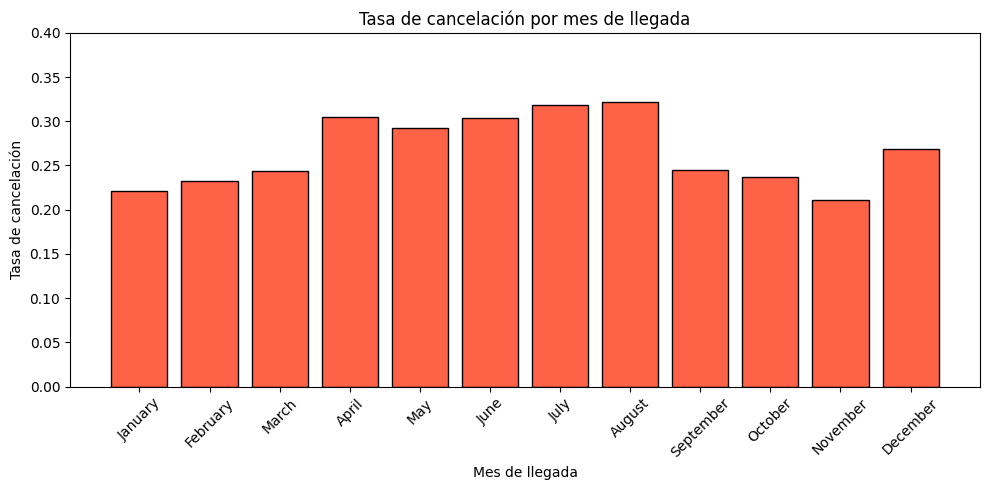

In [ ]:
orden_meses = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_hotel['arrival_date_month'] = pd.Categorical(
    df_hotel['arrival_date_month'],
    categories=orden_meses,
    ordered=True
)

cancelaciones_mes = (
    df_hotel.groupby('arrival_date_month')['is_canceled']
            .mean()
            .reindex(orden_meses)
)

plt.figure(figsize=(10,5))
plt.bar(cancelaciones_mes.index, cancelaciones_mes.values,
        color='tomato', edgecolor='black')

plt.xlabel('Mes de llegada')
plt.ylabel('Tasa de cancelación')
plt.title('Tasa de cancelación por mes de llegada')
plt.ylim(0, 0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

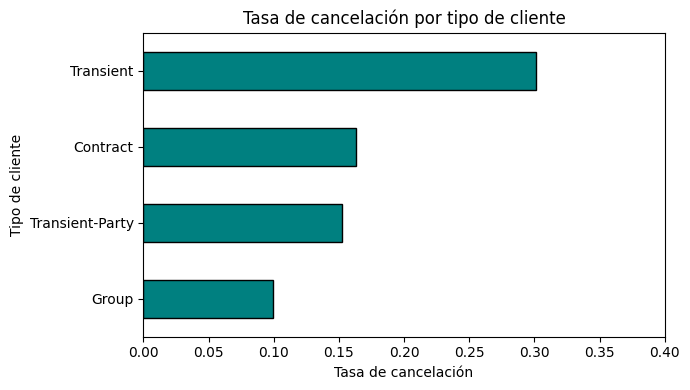

In [ ]:
cancel_cliente = (
    df_hotel.groupby('customer_type')['is_canceled']
            .mean()
            .sort_values(ascending=True)
)

plt.figure(figsize=(7,4))
cancel_cliente.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Tasa de cancelación')
plt.ylabel('Tipo de cliente')
plt.title('Tasa de cancelación por tipo de cliente')
plt.xlim(0, 0.4)
plt.tight_layout()
plt.show()


/tmp/ipython-input-190279904.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hotel.groupby('lead_time_rango')['is_canceled']


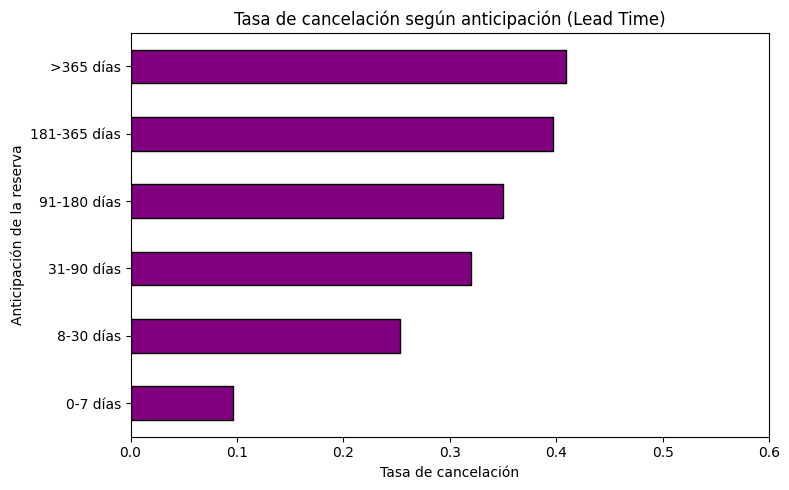

In [ ]:
bins = [0,7,30,90,180,365, df_hotel['lead_time'].max()]
labels = ['0-7 días','8-30 días','31-90 días','91-180 días','181-365 días','>365 días']

df_hotel['lead_time_rango'] = pd.cut(df_hotel['lead_time'], bins=bins, labels=labels)

cancel_lead = (
    df_hotel.groupby('lead_time_rango')['is_canceled']
            .mean()
            .sort_values(ascending=True)
)

plt.figure(figsize=(8,5))
cancel_lead.plot(kind='barh', color='purple', edgecolor='black')

plt.xlabel('Tasa de cancelación')
plt.ylabel('Anticipación de la reserva')
plt.title('Tasa de cancelación según anticipación (Lead Time)')
plt.xlim(0, 0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2803882534.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hotel.groupby('rango_estadia')['is_canceled']


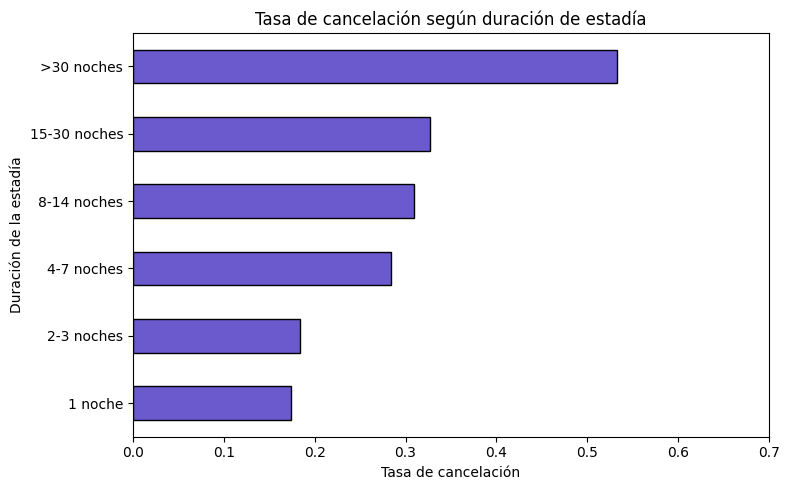

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_hotel['total_noches'] = df_hotel['stays_in_weekend_nights'] + df_hotel['stays_in_week_nights']

labels_noches = ['2-3 noches','4-7 noches','8-14 noches','15-30 noches','>30 noches','1 noche']
bins_noches = [0,1,3,7,14,30, df_hotel['total_noches'].max()]

df_hotel['rango_estadia'] = pd.cut(df_hotel['total_noches'], bins=bins_noches, labels=labels_noches)

cancel_estadia = (
    df_hotel.groupby('rango_estadia')['is_canceled']
            .mean()
            .sort_values(ascending=True)
)

# Graficar barras horizontales
plt.figure(figsize=(8,5))
cancel_estadia.plot(kind='barh', color='slateblue', edgecolor='black')

plt.xlabel('Tasa de cancelación')
plt.ylabel('Duración de la estadía')
plt.title('Tasa de cancelación según duración de estadía')
plt.xlim(0, 0.7)
plt.tight_layout()
plt.show()



**Pregunta 1 (Random Forest)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
y = df_hotel["is_canceled"]

features = ["arrival_date_month", "customer_type", "lead_time", "total_noches",
            "adr", "deposit_type", "market_segment", "arrival_date_year", "arrival_date_day_of_month",
            "stays_in_weekend_nights", "adults", "assigned_room_type", "booking_changes", "days_in_waiting_list",
            "total_of_special_requests", "children", "babies", "meal", "is_repeated_guest",
            "previous_cancellations", "previous_bookings_not_canceled"]

X = df_hotel[features]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print(X.shape, y.shape)


(87396, 21) (87396,)


In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="drop")

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,          # profundidad máxima
    min_samples_split=5,   # mínimo de muestras para dividir un nodo
    random_state=42,
    n_jobs=-1,              # usar todos los núcleos
    class_weight="balanced"
)


# Entrenamiento
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
# Predicciones
y_pred = rf.predict(X_test)
# agregue la probabilidad
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# === Evaluación ===
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.745766590389016

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81     12733
           1       0.52      0.73      0.61      4747

    accuracy                           0.75     17480
   macro avg       0.70      0.74      0.71     17480
weighted avg       0.79      0.75      0.76     17480



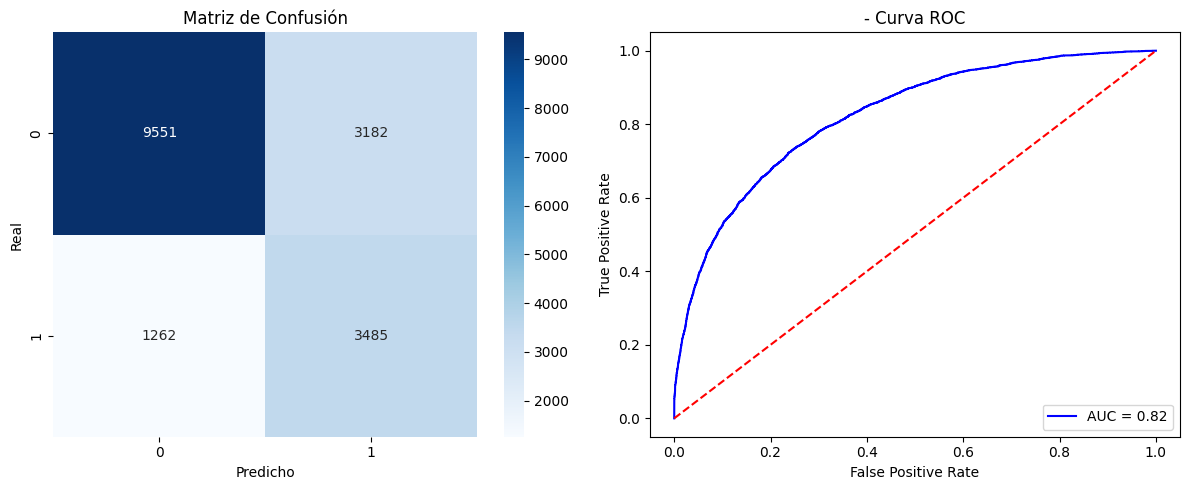

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")

# --- Curva ROC ---

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.subplot(1,2,2)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.title(f"- Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Pregunta 1 (Logistic Regression)**

In [ ]:
# === Variable dependiente (ejemplo: si canceló o no la reserva) ===
y = df_hotel["is_canceled"]

features = ["arrival_date_month", "customer_type", "lead_time", "total_noches",
            "adr", "deposit_type", "market_segment", "arrival_date_year", "arrival_date_day_of_month",
            "stays_in_weekend_nights", "adults", "assigned_room_type", "booking_changes", "days_in_waiting_list",
            "total_of_special_requests", "babies", "meal", "is_repeated_guest",
            "previous_cancellations", "previous_bookings_not_canceled"]

X = df_hotel[features]

# === Detectar columnas numéricas y categóricas ===
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print(X.shape, y.shape)


(87396, 20) (87396,)


In [ ]:
# === Preprocesamiento ===
# Escalar numéricas y aplicar OneHotEncoder a categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="drop")

X_processed = preprocessor.fit_transform(X)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# === Modelo: Regresión Logística ===
log_reg = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced")

# Entrenamiento
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Predicciones
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:,1]

# === Evaluación ===
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6923340961098399
ROC-AUC: 0.7703171757728132

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.76     12733
           1       0.46      0.71      0.56      4747

    accuracy                           0.69     17480
   macro avg       0.66      0.70      0.66     17480
weighted avg       0.75      0.69      0.71     17480



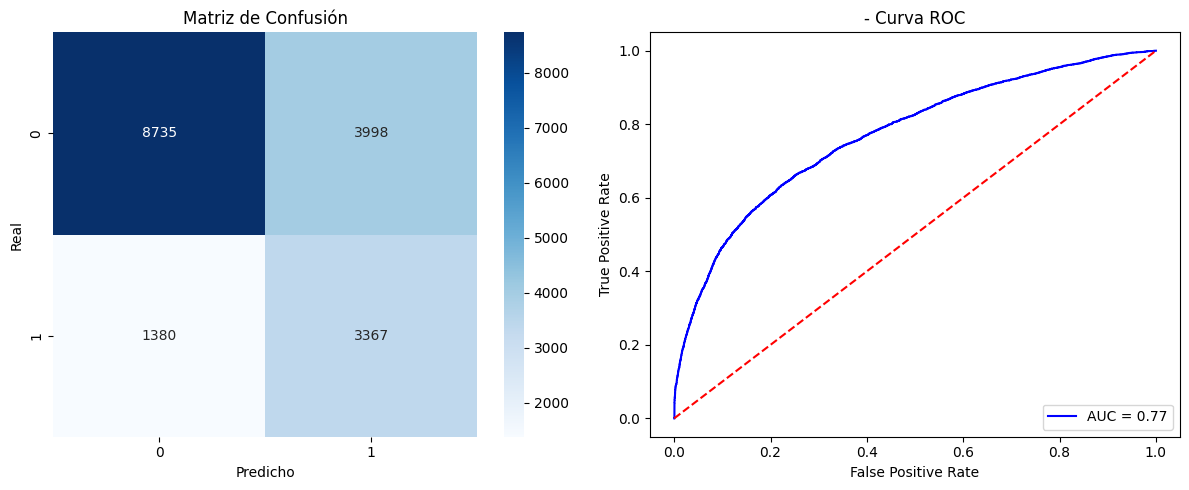

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")

# --- Curva ROC ---

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.subplot(1,2,2)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.title(f"- Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Pregunta 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error

# limpiamos los nulos para poder usar lasso
df_hotel = df_hotel.dropna()

# variable objetivo: ADR
y_adr = df_hotel["adr"]

# elegimos atributos explicativos
features_adr = [
    "hotel",
    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "assigned_room_type",
    "booking_changes",
    "deposit_type",
    "days_in_waiting_list",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_noches"  # variable creada antes
]

# nos quedamos solo con las columnas que existan
features_adr = [columna for columna in features_adr if columna in df_hotel.columns]

X_adr = df_hotel[features_adr]

# columnas numericas y categoricas

num_cols_adr = X_adr.select_dtypes(include =["int64", "float64"]).columns
cat_cols_adr = X_adr.select_dtypes(include =["object", "category"]).columns

print("X_adr shape:", X_adr.shape, "y_adr shape:", y_adr.shape)
print("Numéricas:", list(num_cols_adr))
print("Categóricas:", list(cat_cols_adr))


# preprocesamiento: pasamos escalar a numericas y one hoy a categoricas

preprocessor_adr = ColumnTransformer([
    ("num", StandardScaler(), num_cols_adr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_adr)
], remainder="drop")


# transformamos los datos
X_adr_processed = preprocessor_adr.fit_transform(X_adr)

# train test split
X_adr_train, X_adr_test, y_adr_train, y_adr_test = train_test_split(
    X_adr_processed, y_adr, test_size=0.2, random_state=42
)

# creamos un modelo lineal con lasso para tener pesos y seleccion
lasso = Lasso(alpha = 0.01, random_state = 42)
lasso.fit(X_adr_train, y_adr_train)

# predicciones
y_adr_pred = lasso.predict(X_adr_test)

print("R2 (test):", r2_score(y_adr_test, y_adr_pred))
print("MAE (test):", mean_absolute_error(y_adr_test, y_adr_pred))

X_adr shape: (80702, 28) y_adr shape: (80702,)
Numéricas: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests', 'total_noches']
Categóricas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
R2 (test): 0.65907286588399
MAE (test): 22.16252687434128


### Calculamos los pesos

In [ ]:
# obtenemos nombres de las columnas después de one-hot
from sklearn.preprocessing import OneHotEncoder

ohe_adr = preprocessor_adr.named_transformers_["cat"]
ohe_feature_names_adr = ohe_adr.get_feature_names_out(cat_cols_adr)

# concatenamos numéricas + dummies
all_feature_names_adr = np.concatenate([num_cols_adr, ohe_feature_names_adr])

# coeficientes del modelo
coef_adr = lasso.coef_

print("len features:", len(all_feature_names_adr))
print("len coef:", len(coef_adr))

coef_df_adr = pd.DataFrame({
    "feature": all_feature_names_adr,
    "coef": coef_adr
})

coef_df_adr["abs_coef"] = coef_df_adr["coef"].abs()
coef_df_adr = coef_df_adr.sort_values("abs_coef", ascending=False)

# imprimimos las 20 variables con mayor peso absoluto
print(coef_df_adr.head(20))

len features: 246
len coef: 246
                          feature       coef   abs_coef
210  market_segment_Complementary -88.994844  88.994844
35                        meal_SC -45.200132  45.200132
21      arrival_date_month_August  43.467686  43.467686
228          reserved_room_type_H  42.979421  42.979421
222          reserved_room_type_B -40.251530  40.251530
25        arrival_date_month_July  31.261564  31.261564
32                        meal_BB -30.583565  30.583565
227          reserved_room_type_G  27.660747  27.660747
238          assigned_room_type_K -26.902470  26.902470
24     arrival_date_month_January -26.838664  26.838664
221          reserved_room_type_A -25.775413  25.775413
23    arrival_date_month_February -25.105996  25.105996
215      market_segment_Online TA  23.330417  23.330417
18               hotel_City Hotel  21.799588  21.799588
33                        meal_FB  21.107077  21.107077
31   arrival_date_month_September  20.994702  20.994702
239       deposi

### Correlacion y sesgo

adr                               1.000000
children                          0.332526
adults                            0.230014
arrival_date_year                 0.177185
total_of_special_requests         0.132594
is_canceled                       0.114237
arrival_date_week_number          0.092411
required_car_parking_spaces       0.048495
arrival_date_day_of_month         0.022463
babies                            0.020682
stays_in_week_nights              0.018294
total_noches                      0.016975
stays_in_weekend_nights           0.008923
booking_changes                   0.004221
lead_time                        -0.011215
days_in_waiting_list             -0.037883
previous_cancellations           -0.048129
previous_bookings_not_canceled   -0.070469
is_repeated_guest                -0.113184
Name: adr, dtype: float64


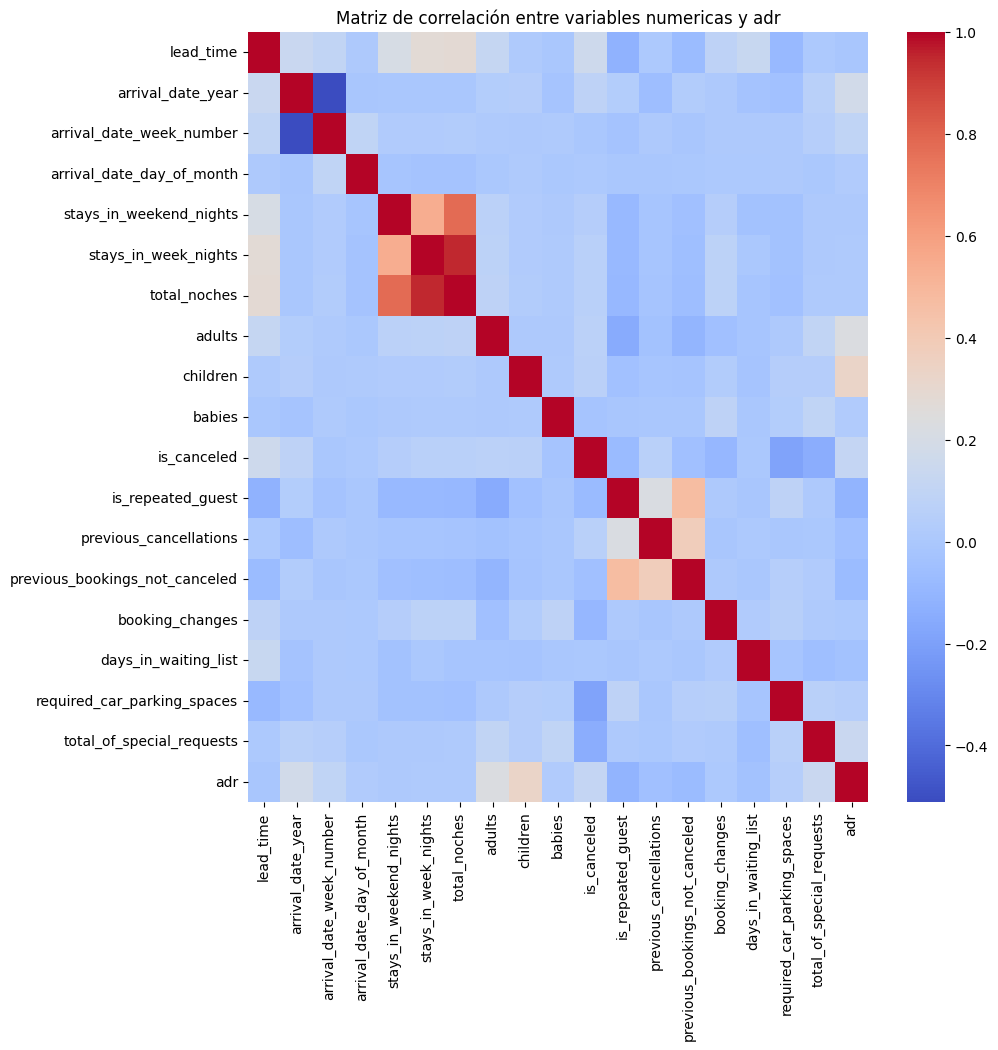

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


num_corr_cols = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_noches",
    "adults",
    "children",
    "babies",
    "is_canceled",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr"
]

num_corr_cols = [columnas for columnas in num_corr_cols if columnas in df_hotel.columns]

corr_matrix = df_hotel[num_corr_cols].corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación entre variables numericas y adr")
plt.show


# correlacion especifica con adr
print(corr_matrix["adr"].sort_values(ascending=False))

### Seleccionamos los atributos

In [ ]:
# atributos con coeficientes distintos de 0 excluyendo los que son insignificantes
selected_features_adr = coef_df_adr[coef_df_adr["abs_coef"]> 1e-4].copy()

print("Numero total de atributos despues del one hot:", len(coef_df_adr))
print("Numero de atributos seleccionados por lasso:", len(selected_features_adr))
print(selected_features_adr.head(30))

Numero total de atributos despues del one hot: 246
Numero de atributos seleccionados por lasso: 84
                          feature       coef   abs_coef
210  market_segment_Complementary -88.994844  88.994844
35                        meal_SC -45.200132  45.200132
21      arrival_date_month_August  43.467686  43.467686
228          reserved_room_type_H  42.979421  42.979421
222          reserved_room_type_B -40.251530  40.251530
25        arrival_date_month_July  31.261564  31.261564
32                        meal_BB -30.583565  30.583565
227          reserved_room_type_G  27.660747  27.660747
238          assigned_room_type_K -26.902470  26.902470
24     arrival_date_month_January -26.838664  26.838664
221          reserved_room_type_A -25.775413  25.775413
23    arrival_date_month_February -25.105996  25.105996
215      market_segment_Online TA  23.330417  23.330417
18               hotel_City Hotel  21.799588  21.799588
33                        meal_FB  21.107077  21.107077
31   

## Pregunta 3


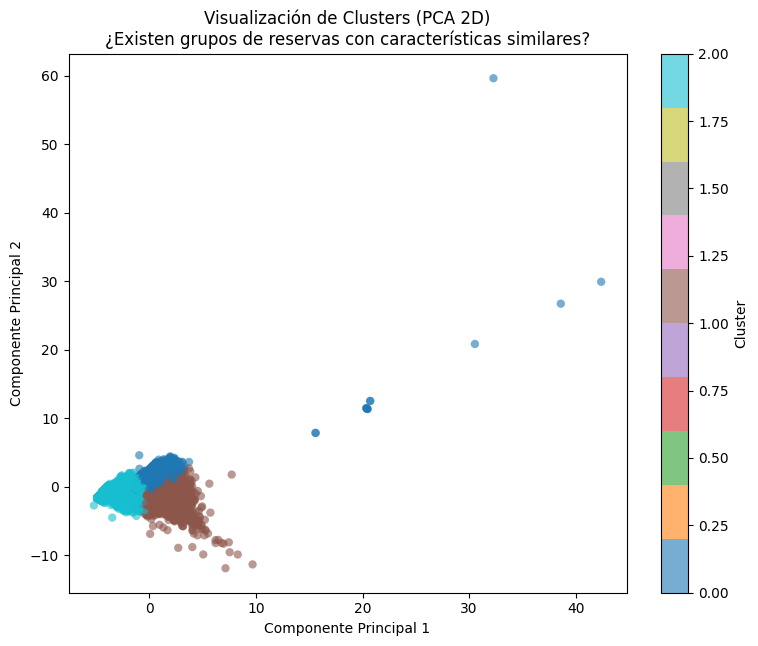

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
numeric_vars = ["lead_time", "adr", "total_noches", "adults"]
categorical_encoded = [col for col in df_hotel.columns
                       if df_hotel[col].dtype in ["int64", "float64"]
                       and col not in numeric_vars
                       and col not in ["is_canceled"]  # excluir si existe
                       and df_hotel[col].nunique() == 2]
features = numeric_vars + categorical_encoded
X = df_hotel[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=30)

df_hotel["cluster"] = kmeans_final.fit_predict(X_scaled)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 componentes principales usando los datos escalados del clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_hotel["pca1"] = X_pca[:,0]
df_hotel["pca2"] = X_pca[:,1]

plt.figure(figsize=(9,7))
scatter = plt.scatter(
    df_hotel["pca1"],
    df_hotel["pca2"],
    c=df_hotel["cluster"],
    cmap="tab10",
    alpha=0.6,
    edgecolor="none"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de Clusters (PCA 2D)\n¿Existen grupos de reservas con características similares?")
plt.colorbar(scatter, label="Cluster")
plt.show()


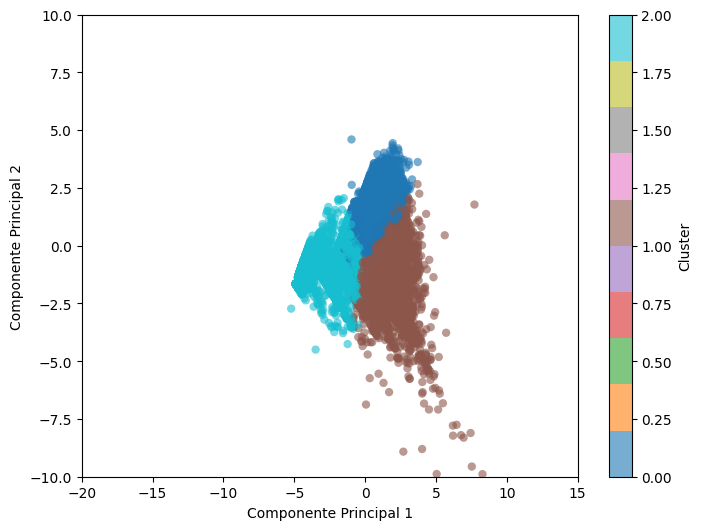

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df_hotel["pca1"],
    df_hotel["pca2"],
    c=df_hotel["cluster"],
    cmap="tab10",
    alpha=0.6,
    edgecolor="none"
)
plt.xlim(-20, 15)
plt.ylim(-10, 10)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

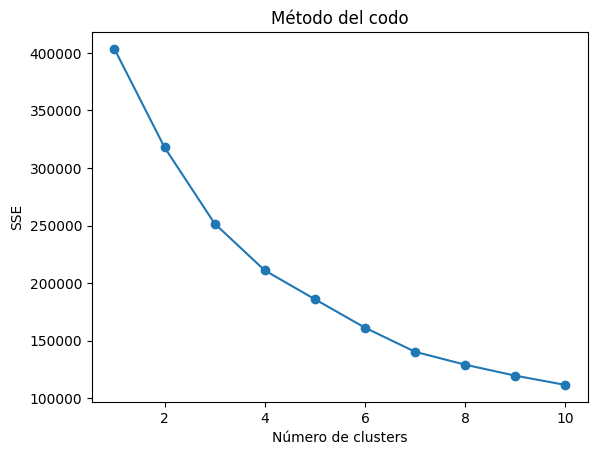

In [ ]:
#ahora con metodo del codo
Ks=range(1,11)
sse = []
for k in Ks:
  kmeans = KMeans(n_clusters=k, random_state=30, n_init=10)
  kmeans.fit(X_scaled)
  sse.append(kmeans.inertia_)
plt.plot(Ks, sse, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('SSE')
plt.title('Método del codo')
plt.show()

K elegido : k= 3

In [ ]:
#Perfil de cada cluster

resumen_clusters = (
    df_hotel
    .groupby("cluster")[["lead_time", "adr", "total_noches", "adults"]]
    .median()
    .round(2)
)
print(resumen_clusters)

# Tamaño de cada cluster
tam_clusters = df_hotel["cluster"].value_counts().sort_index()
print(tam_clusters)

         lead_time    adr  total_noches  adults
cluster                                        
0             40.0  109.0           3.0     2.0
1            187.0   96.3           6.0     2.0
2             14.0   79.0           2.0     1.0
cluster
0    47120
1    20997
2    12585
Name: count, dtype: int64


In [ ]:
#categoría
if "is_canceled" in df_hotel.columns:
    cancel_por_cluster = (
        df_hotel
        .groupby("cluster")["is_canceled"]
        .mean()
        .round(3)
    )
    print(cancel_por_cluster)

cluster
0    0.286
1    0.368
2    0.192
Name: is_canceled, dtype: float64


#Conclusión

Los resultados muestran que añadir más variables y aplicar técnicas de balanceo mejoró el rendimiento de los modelos, especialmente al identificar la clase minoritaria (cancelaciones), reflejado en un mejor F1-score . Sin embargo, los modelos aún presentan dificultades para separar correctamente reservas canceladas de las que no lo están, lo que sugiere que parte del comportamiento real no está siendo capturado por los atributos disponibles. En paralelo, el análisis del ADR y la segmentación mediante clustering aportó una visión complementaria sobre los factores que influyen en el precio y en los distintos perfiles de reserva, reforzando la idea de que el comportamiento de los huéspedes es multifactorial y no se explica por una sola dimensión.

Posibles mejoras:

Es necesario ampliar la información utilizada por los modelos, incorporando variables externas como estacionalidad, eventos especiales, historial del cliente o políticas de precios, que podrían aportar contexto adicional. También sería valioso probar algoritmos más avanzados, como XGBoost o LightGBM, que suelen ofrecer mejor desempeño en problemas con patrones complejos y relaciones no lineales. Junto con eso, conviene explorar técnicas más robustas para enfrentar el desbalance de clases, tales como SMOTE o ADASYN, que podrían complementar o superar el uso actual de class_weight. Finalmente, integrar estas mejoras en un pipeline reproducible permitiría evaluar eficazmente nuevas iteraciones y avanzar hacia modelos más estables y útiles para la toma de decisiones hoteleras.

#Citas a fuentes externas

1. Antonio, N., Almeida, A., & Nunes, L. (2019). Hotel Booking Demand Datasets.
https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

2. scikit-learn Developers. (2024). Scikit-learn Documentation.
https://scikit-learn.org/stable/

3. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12.

4. Pandas Development Team. (2024). pandas: Python Data Analysis Library.

5. Matplotlib Development Team. (2024). Matplotlib Documentation.